# Time-Aware GAT — Next-Event Prediction on Helpdesk

This notebook demonstrates **next-event prediction** using the **Time-Aware Dual-GAT**
on the Helpdesk event log.

## Model overview

| Component | Description |
|-----------|-------------|
| Architecture | Dual-GAT with a custom `TimeAwareGATConv` layer |
| Time decay | Attention scores are modulated by exponential decay: **α′ = α · exp(−λ Δt)** |
| Effect | Recent events receive higher attention; distant past is discounted |
| Attention output | The recipe returns per-graph attention maps for analysis |

The key idea: in process mining, **how long ago** an event occurred is as important
as **what** occurred. The learnable decay parameter λ controls how aggressive
the temporal discounting is.

### Notebook outline
1. Load & Explore the Dataset
2. Train the Model
3. Evaluate with Comprehensive Metrics
4. Attention Analysis & Visualisations
5. Summary

In [1]:
from pathlib import Path
import sys, warnings

root = Path.cwd().resolve()
src = root / "src" if (root / "src").exists() else root.parent / "src"
sys.path.insert(0, str(src))
warnings.filterwarnings("ignore", category=FutureWarning)

## 1. Load & Explore the Dataset

In [2]:
import pandas as pd

data_dir = Path.cwd() / "data" if (Path.cwd() / "data").exists() else Path.cwd() / "examples" / "data"
df = pd.read_csv(data_dir / "Helpdesk.csv")

df = df.rename(columns={
    "case:concept:name": "case_id",
    "concept:name":      "event",
    "time:timestamp":    "time",
    "lifecycle:transition": "status",
    "case:variant-index":   "variant_index",
})
df = df.dropna(subset=["case_id", "event", "time"]).copy()
df["time"] = pd.to_datetime(df["time"], utc=True)
df = df[df.groupby("case_id")["case_id"].transform("size") >= 2].reset_index(drop=True)

print(f"Cases: {df['case_id'].nunique()}  |  Events: {len(df)}  |  Activities: {df['event'].nunique()}")
df.head()

Cases: 4580  |  Events: 21348  |  Activities: 14


,event,status,org:resource,time,Activity,Resource,case_id,case:variant,variant_index,case:creator
0,Assign seriousness,complete,Value 2,2010-01-13 08:40:25+00:00,Assign seriousness,Value 2,Case3608,Variant 33,33,Fluxicon Disco
1,Take in charge ticket,complete,Value 2,2010-01-29 08:52:27+00:00,Take in charge ticket,Value 2,Case3608,Variant 33,33,Fluxicon Disco
2,Resolve ticket,complete,Value 2,2010-01-29 08:52:34+00:00,Resolve ticket,Value 2,Case3608,Variant 33,33,Fluxicon Disco
3,Closed,complete,Value 5,2010-02-13 08:52:48+00:00,Closed,Value 5,Case3608,Variant 33,33,Fluxicon Disco
4,Closed,complete,Value 5,2010-02-13 08:52:48+00:00,Closed,Value 5,Case3608,Variant 33,33,Fluxicon Disco


## 2. Train the Model

The `gat_time_decay` recipe uses the same interface as `gat_basic` but internally
constructs `TimeAwareGATConv` layers with a learnable `lambda_decay` parameter.

After training, `result["attention"]` contains per-graph attention maps
that we can visualise in §4.

In [ ]:
from timegnn import GATTimeDecayConfig, gat_time_decay

cfg = GATTimeDecayConfig(
    num_layers=3,
    dropout=0.20,
    use_batch_norm=True,
    activation="gelu",
    lambda_decay=0.01,
    num_epochs=30,
    patience=5,
    delta=1e-4,
    batch_size=16,
)

result = gat_time_decay(
    df,
    case_col="case_id",
    event_col="event",
    time_col="time",
    cat_event=["event"],
    num_event=[],
    seq_cols=["variant_index"],
    cat_seq=[],
    num_seq=["variant_index"],
    config=cfg,
)

model = result["model"]
pd.DataFrame(result["history"])

,epoch,train_loss,train_acc,test_loss,test_acc
0,1,1.421513,0.677408,2.087014,0.655103
1,2,1.209847,0.705537,1.209763,0.662219
2,3,1.072307,0.711471,1.123621,0.660440


## Visualize Model Topology

After training, you can render the network topology to understand the structure and trainable parameters.

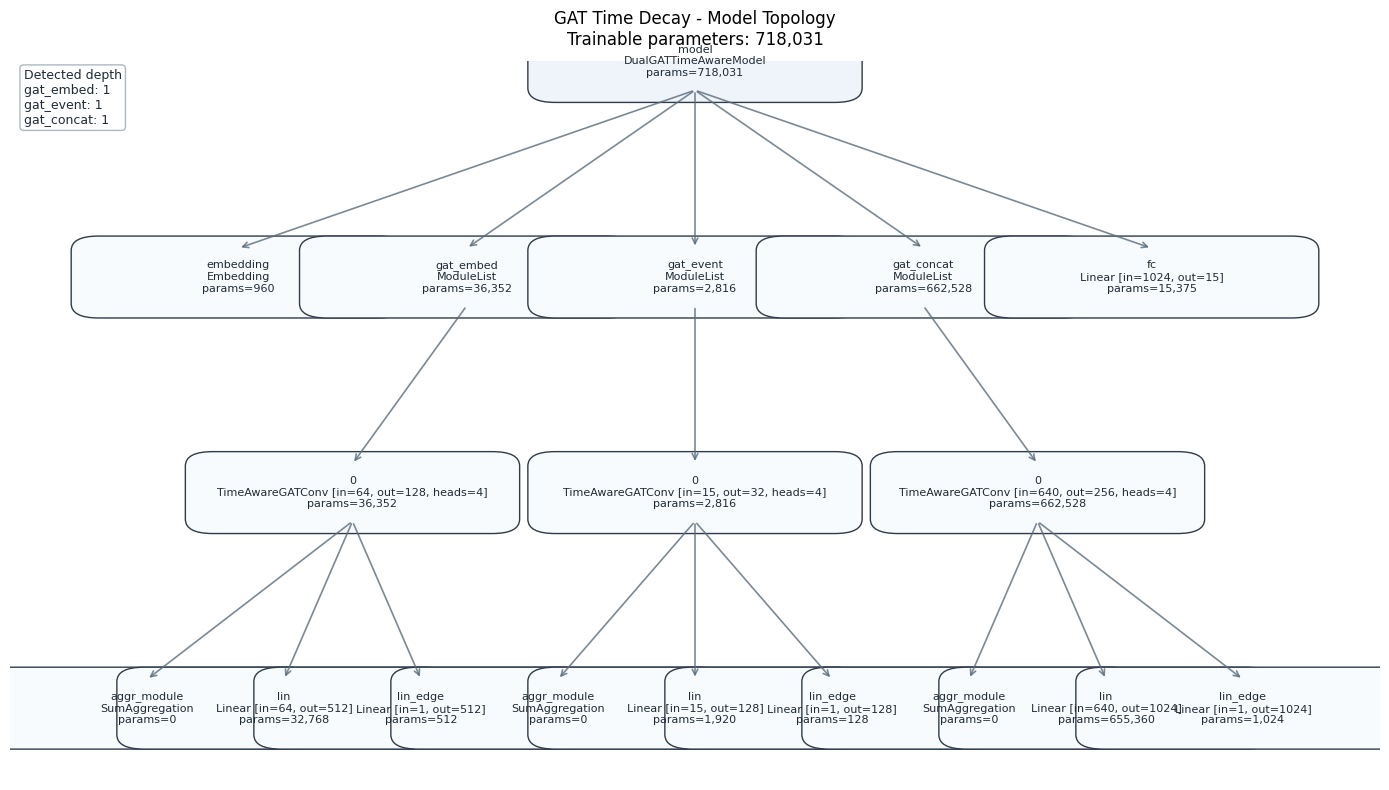

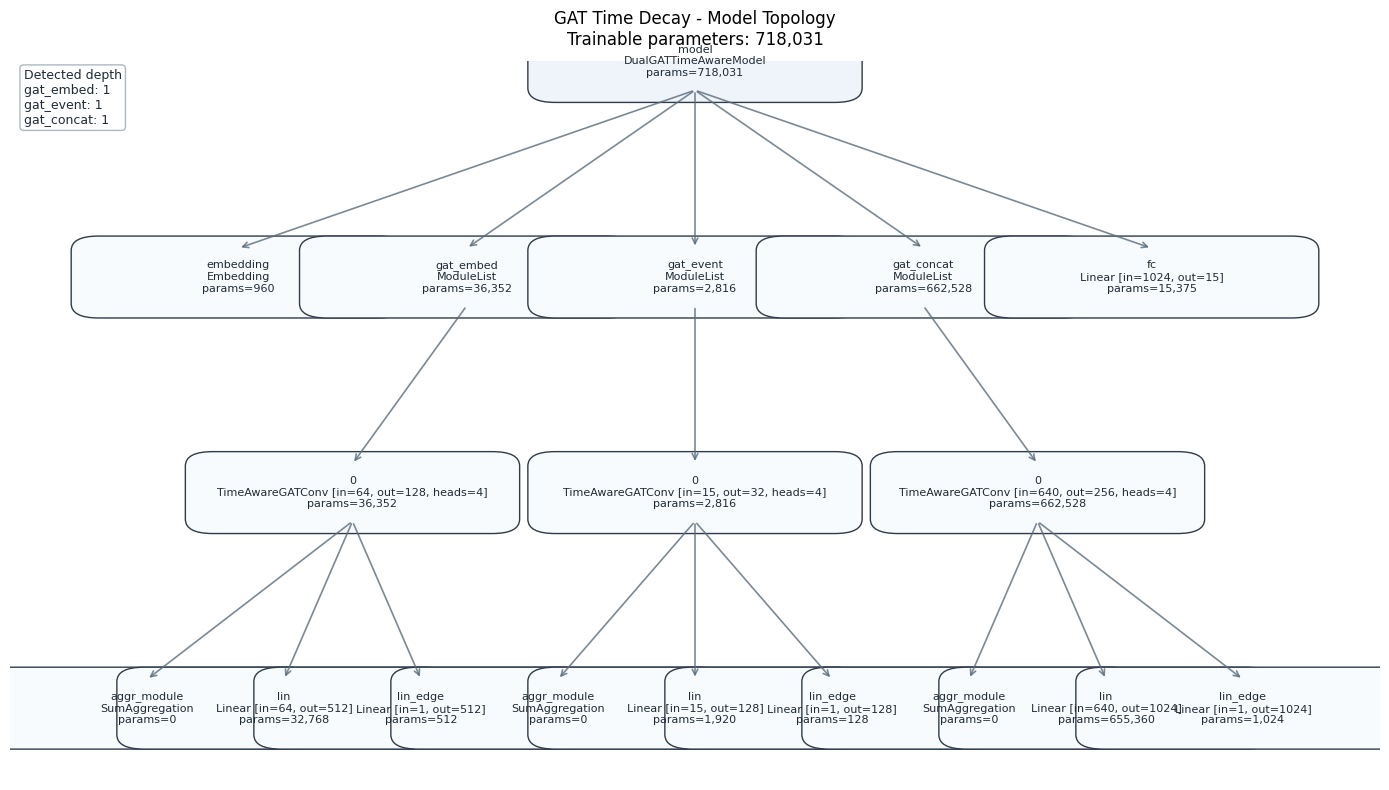

In [4]:
from timegnn import plot_model_topology

fig, ax = plot_model_topology(
    model,
    max_depth=4,
    title="GAT Time Decay - Model Topology",
)
fig

## 3. Evaluate with Comprehensive Metrics

In [5]:
import torch
from torch.utils.data import DataLoader
from timegnn import (
    EventLogTransformer, top_k_accuracy, predict, predict_per_sequence,
    average_bleu_score, compute_dls_and_exact_match, analyze_sequence_errors,
)
from timegnn.data.pyg import CustomDataset, custom_collate_fn

transformer = EventLogTransformer(
    case_col="case_id", event_col="event", time_col="time",
    cat_event=["event"], num_event=[],
    seq_cols=["variant_index"], cat_seq=[], num_seq=["variant_index"],
    mode="gat_time_decay",
).fit(df)

transformed = transformer.transform(df)
dataset = CustomDataset(transformed.event_features, transformed.labels)
loader  = DataLoader(dataset, batch_size=16, shuffle=False, collate_fn=custom_collate_fn)

device = "cuda" if torch.cuda.is_available() else "cpu"
model  = model.to(device)

preds_flat, labels_flat, outputs = predict(model, loader, device)
print(f"Top-1 accuracy: {top_k_accuracy(outputs, labels_flat, k=1):.4f}")
print(f"Top-3 accuracy: {top_k_accuracy(outputs, labels_flat, k=3):.4f}")
print(f"Top-5 accuracy: {top_k_accuracy(outputs, labels_flat, k=5):.4f}")

preds_seq, labels_seq = predict_per_sequence(model, loader, device)
bleu = average_bleu_score(preds_seq, labels_seq)
dls, exact = compute_dls_and_exact_match(preds_seq, labels_seq)
print(f"\nBLEU:  {bleu:.4f}")
print(f"DLS:   {dls:.4f}")
print(f"Exact: {exact:.4f}")

print("\nSequence error summary:")
print(analyze_sequence_errors(model, loader, device))

Top-1 accuracy: 0.7025
Top-3 accuracy: 0.9532
Top-5 accuracy: 0.9919

BLEU:  0.2397
DLS:   0.7059
Exact: 0.0081

Sequence error summary:
(array([ 868, 4063,  765,  346,  146,   83,   40,   19,   11,    7,    2,
          0,    1]), {(12, 10): 3148, (12, 8): 103, (12, 0): 552, (12, 14): 1119, (12, 1): 270, (10, 12): 367, (1, 10): 163, (10, 2): 18, (14, 2): 1, (10, 14): 300, (1, 12): 111, (12, 11): 5, (12, 2): 47, (14, 10): 60, (10, 4): 10, (4, 1): 14, (1, 7): 2, (12, 5): 1, (13, 1): 1, (10, 13): 2, (10, 8): 13, (12, 9): 9, (4, 12): 1, (4, 10): 1, (1, 8): 1, (14, 12): 4, (1, 4): 8, (1, 14): 3, (14, 8): 1, (10, 0): 1, (8, 10): 2, (1, 0): 1, (12, 4): 6, (10, 9): 3, (10, 5): 1, (0, 9): 1, (10, 3): 1}, {'min': 2, 'max': 15, 'mean': np.float64(4.661135371179039), 'median': np.float64(4.0)})


## 4. Attention Analysis & Visualisations

The time-aware model records attention weights and decay factors.
We can analyse **which events the model attends to** and how temporal
distance modulates those attention scores.

The visualisation pipeline:
1. Bin sequences by length
2. Compute importance = attention × decay per node rank
3. Plot heatmaps, rank-dominance charts, and temporal windows

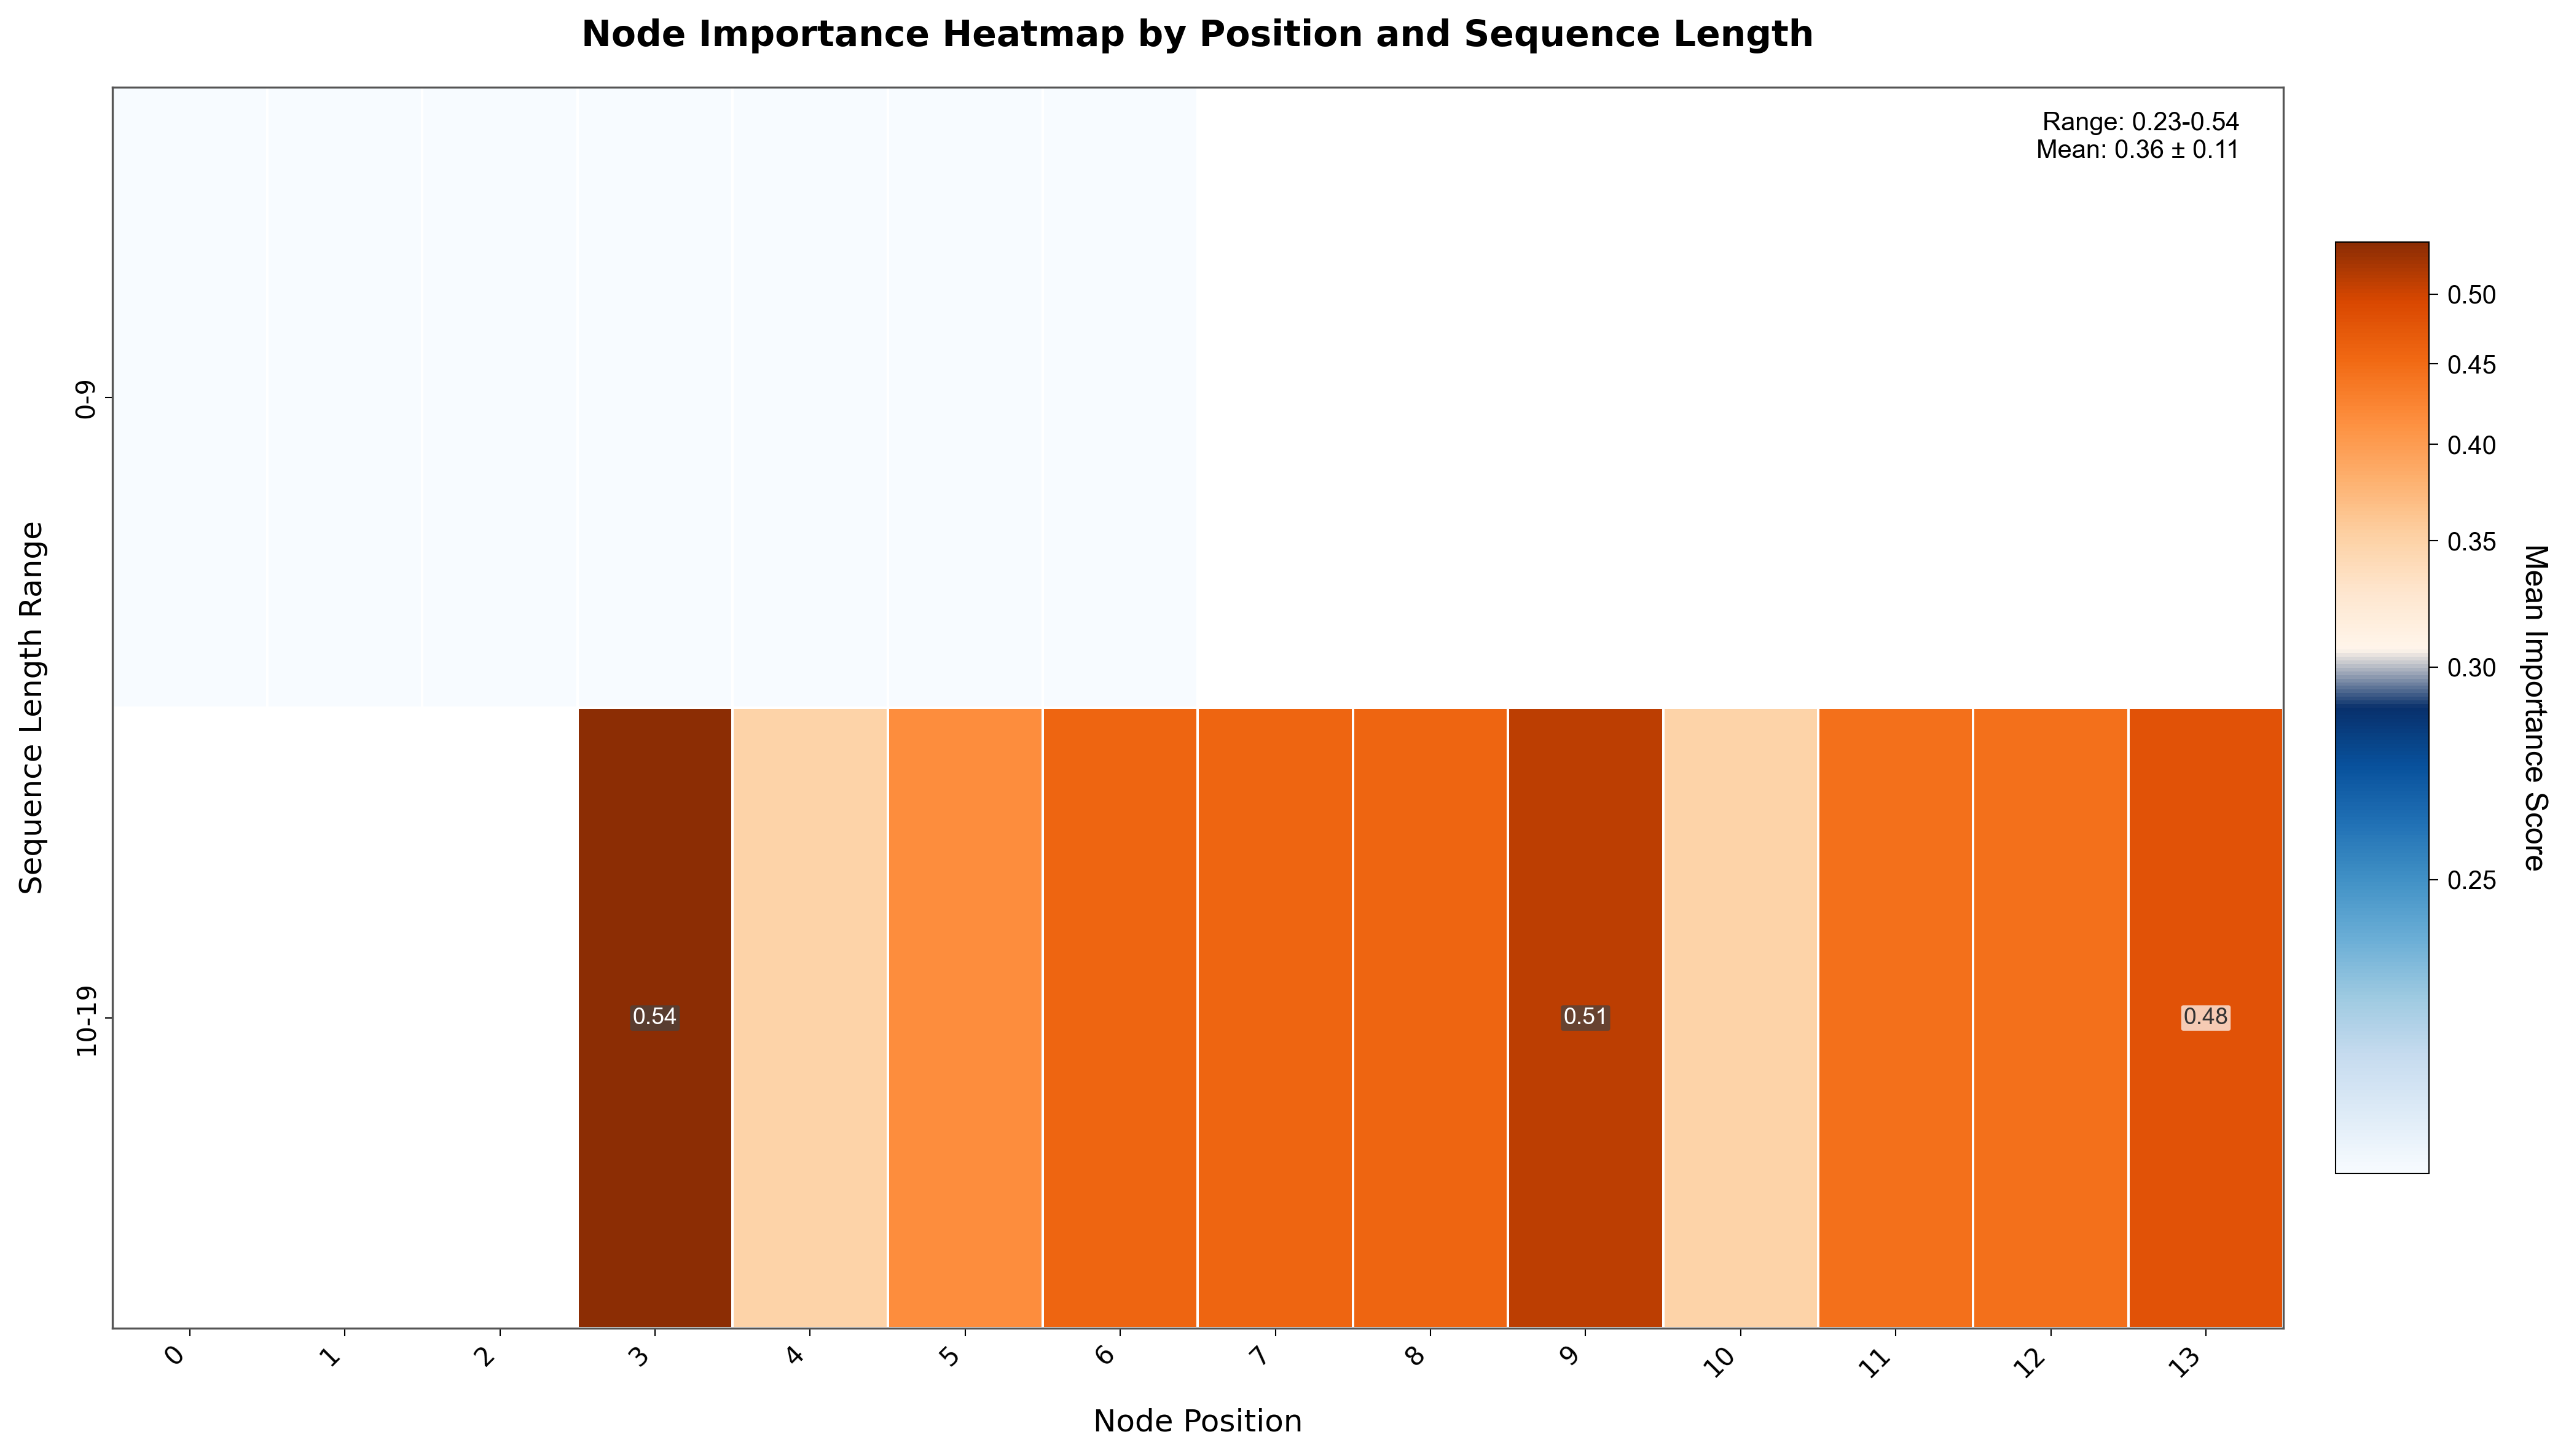

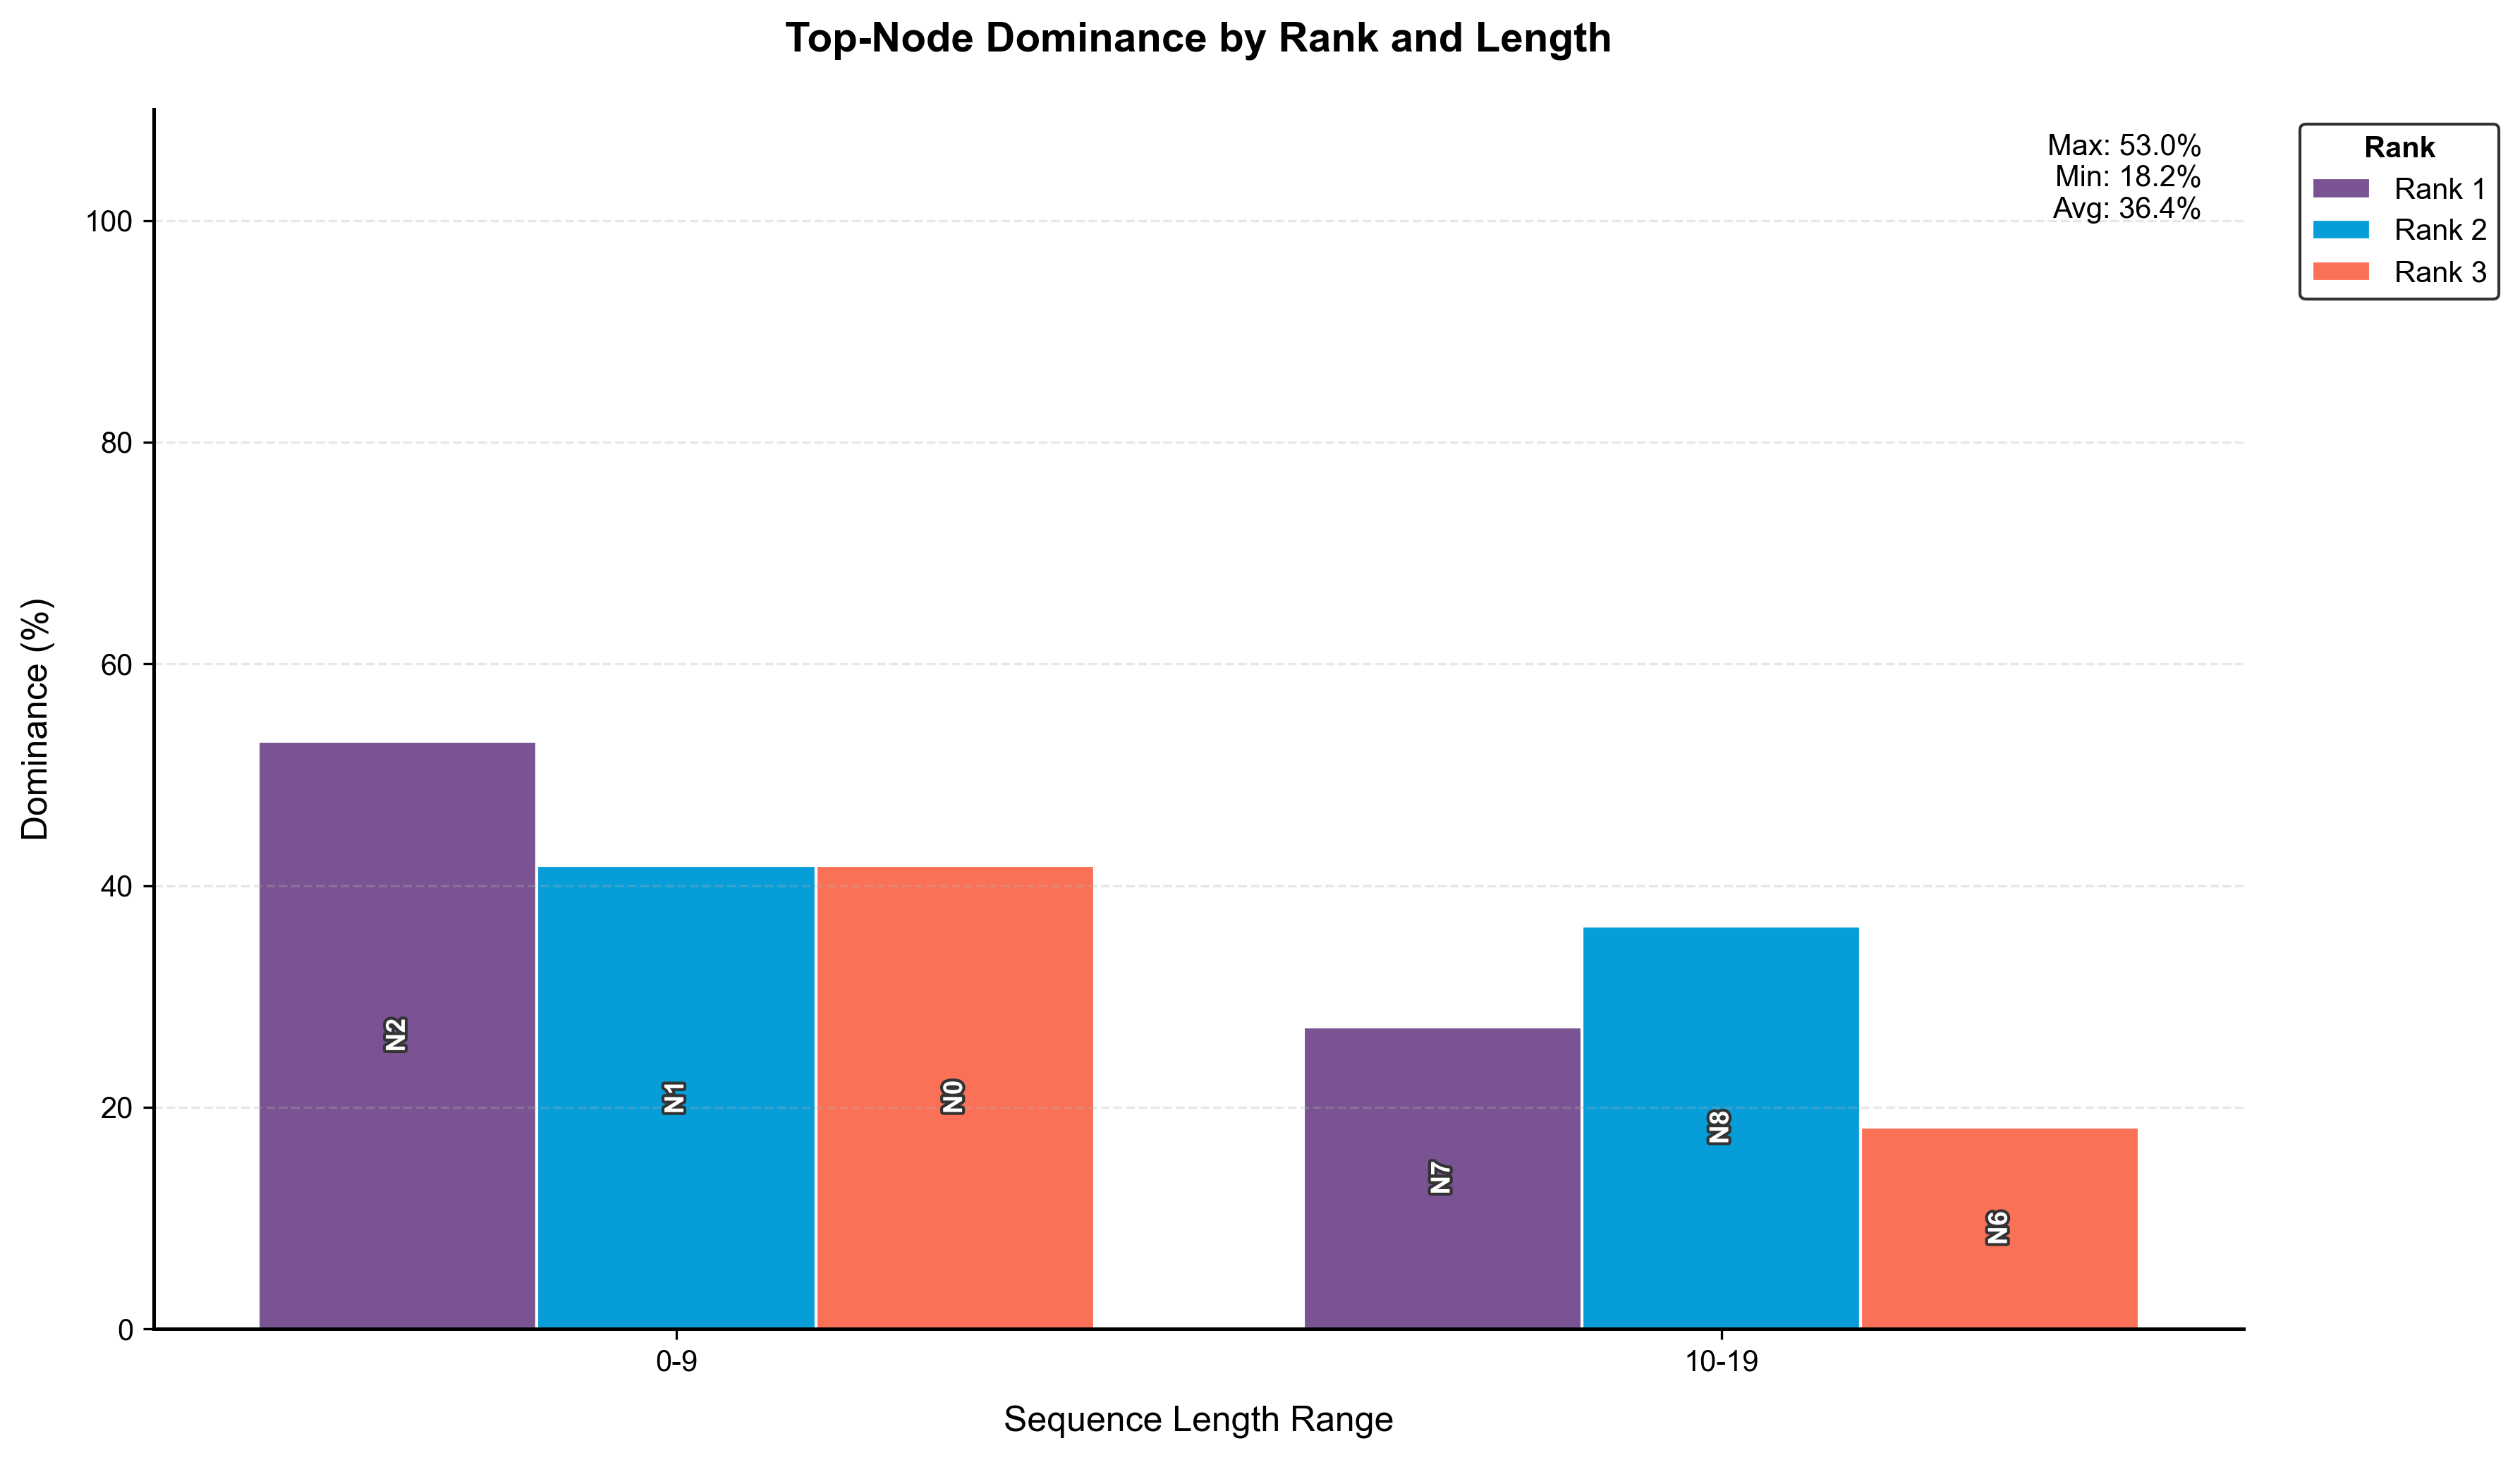

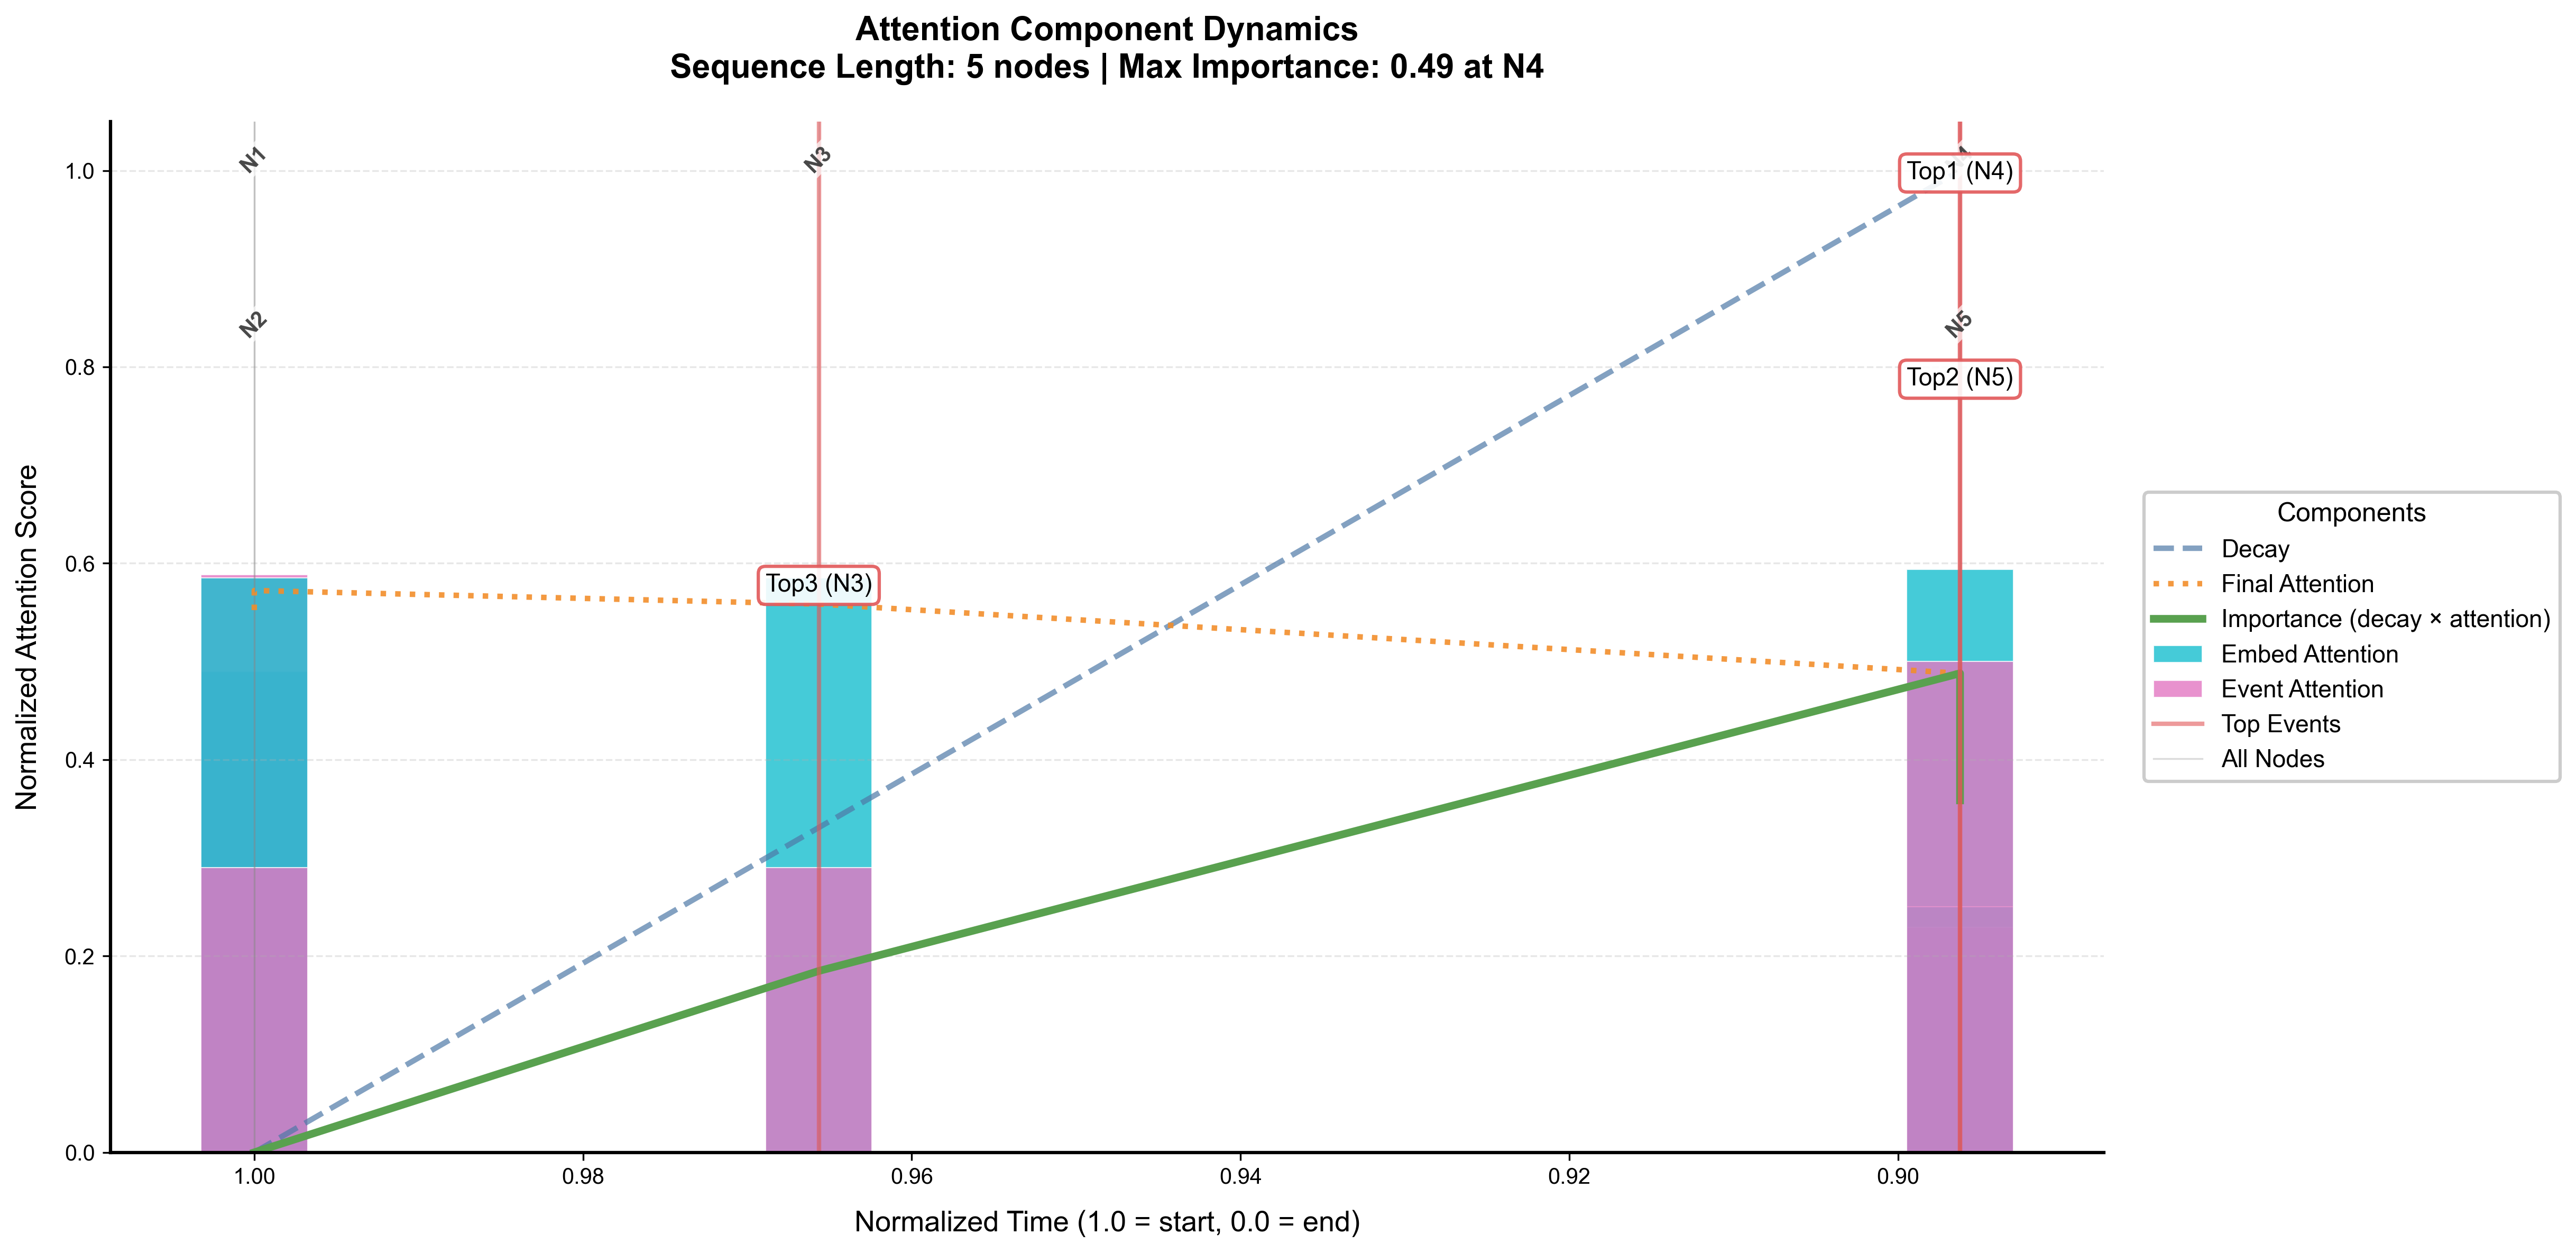

<Figure size 640x480 with 0 Axes>

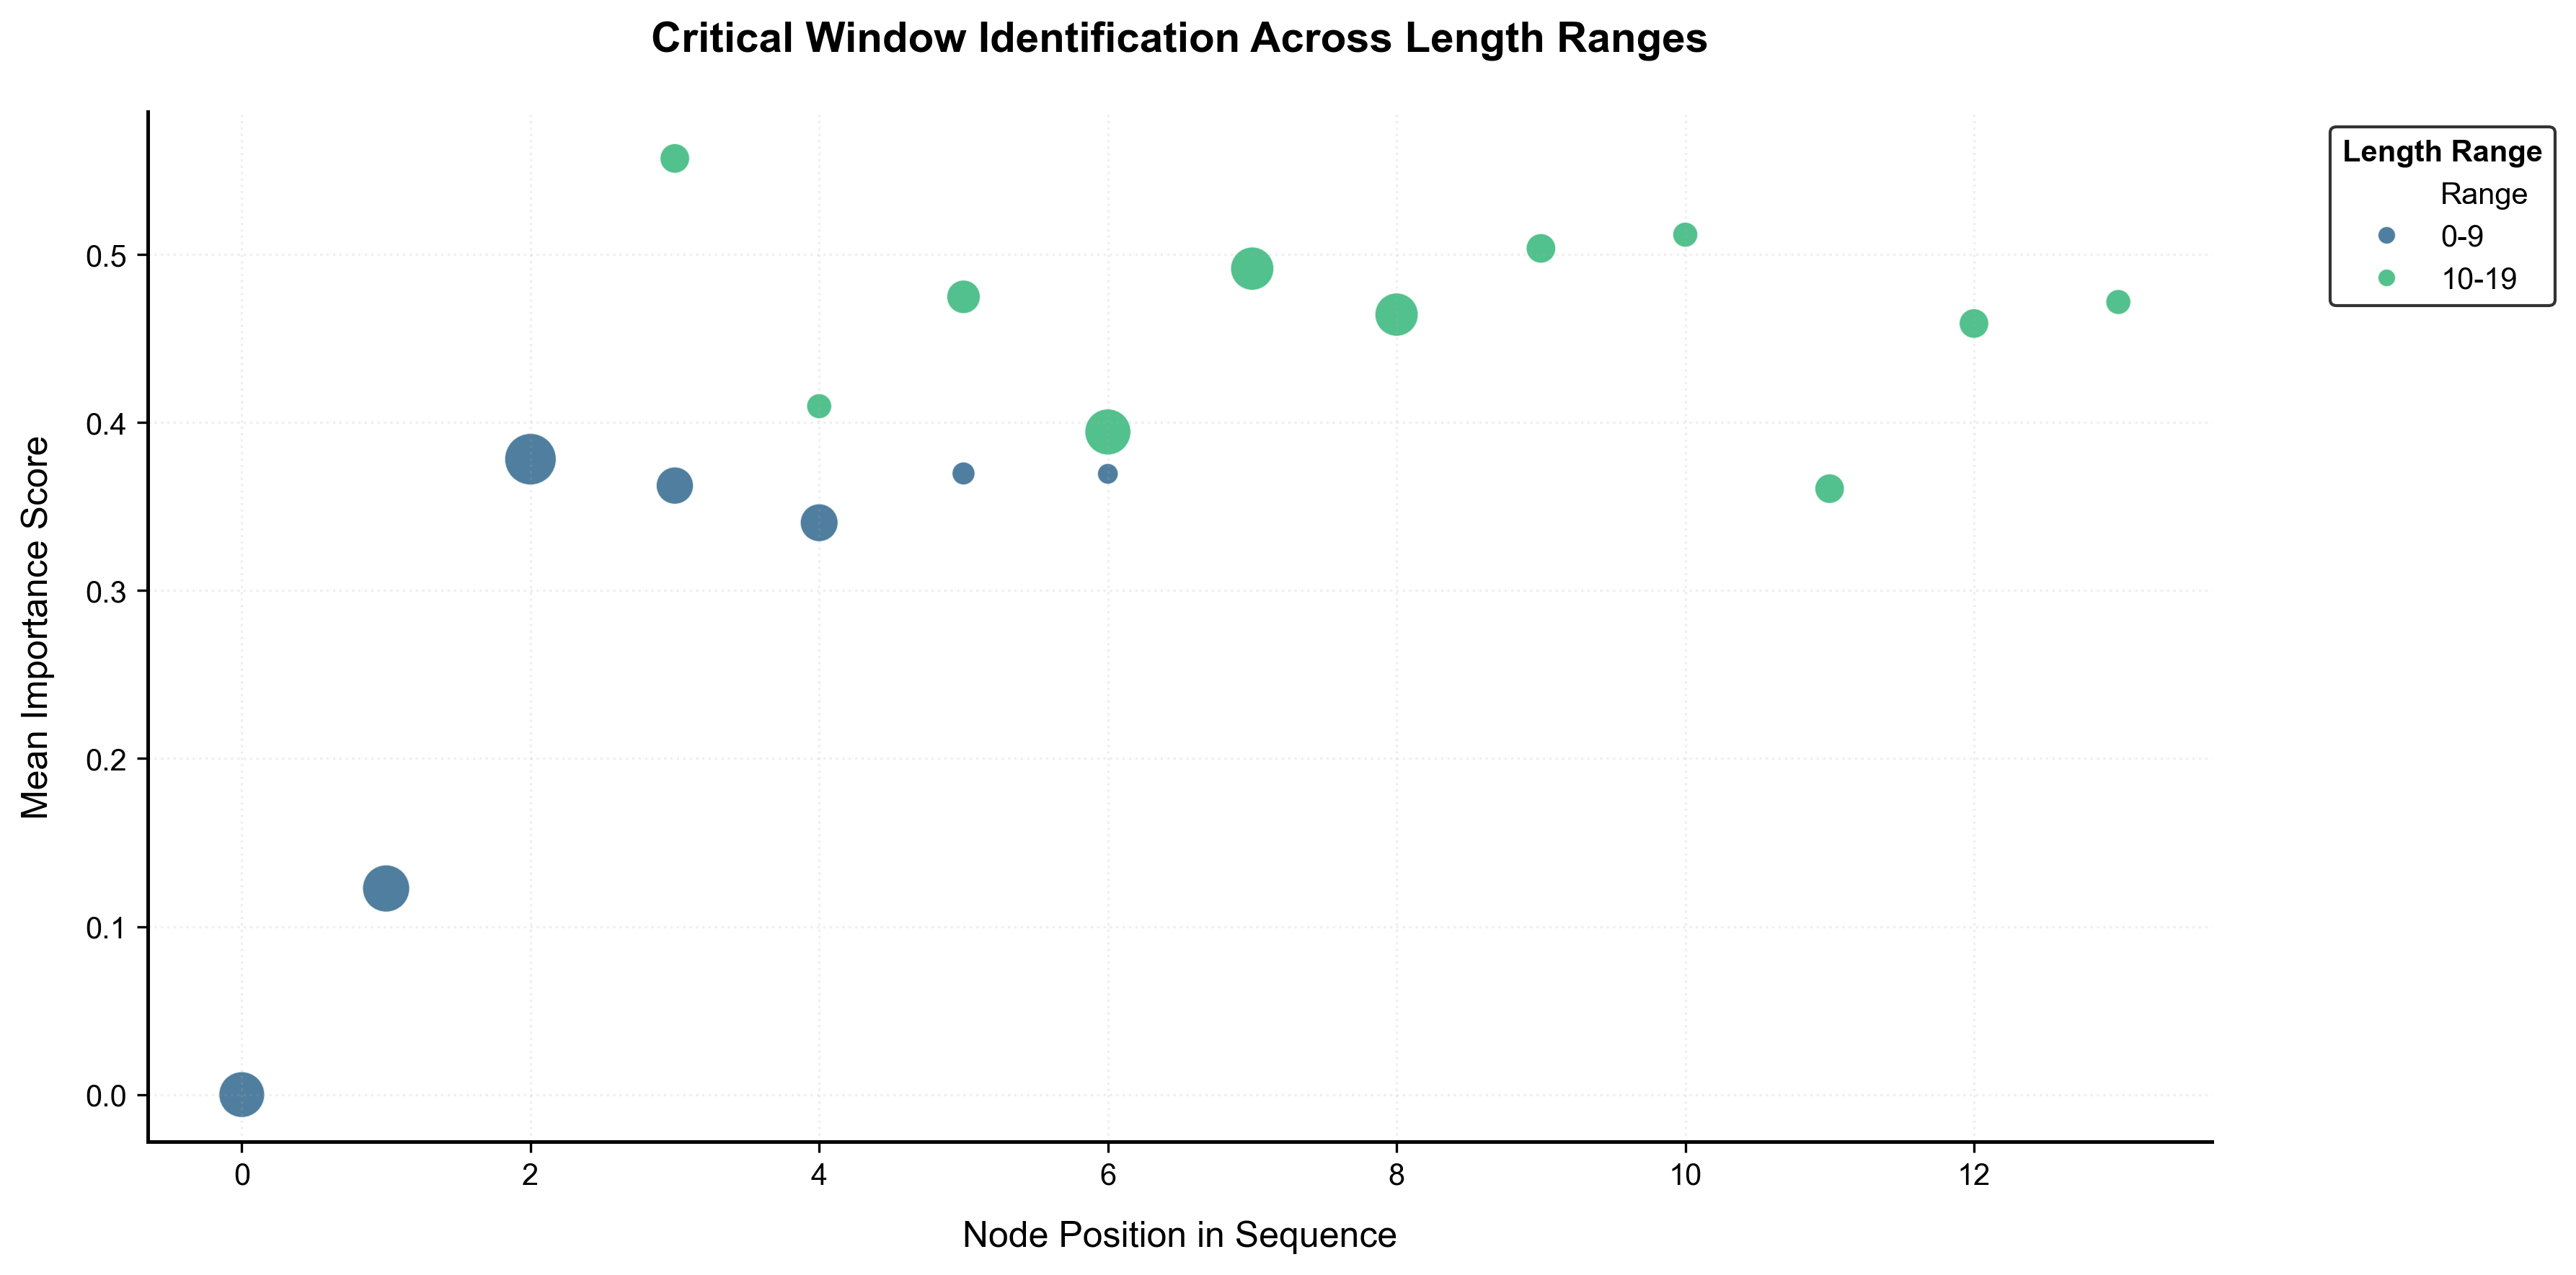

     Comparison Mean Diff t-statistic    p-value Cohen's d Significance  n1  \
0  0-9 vs 10-19    -0.186       -3.72  1.869e-03     -1.80           **   7   

   n2  
0  11  


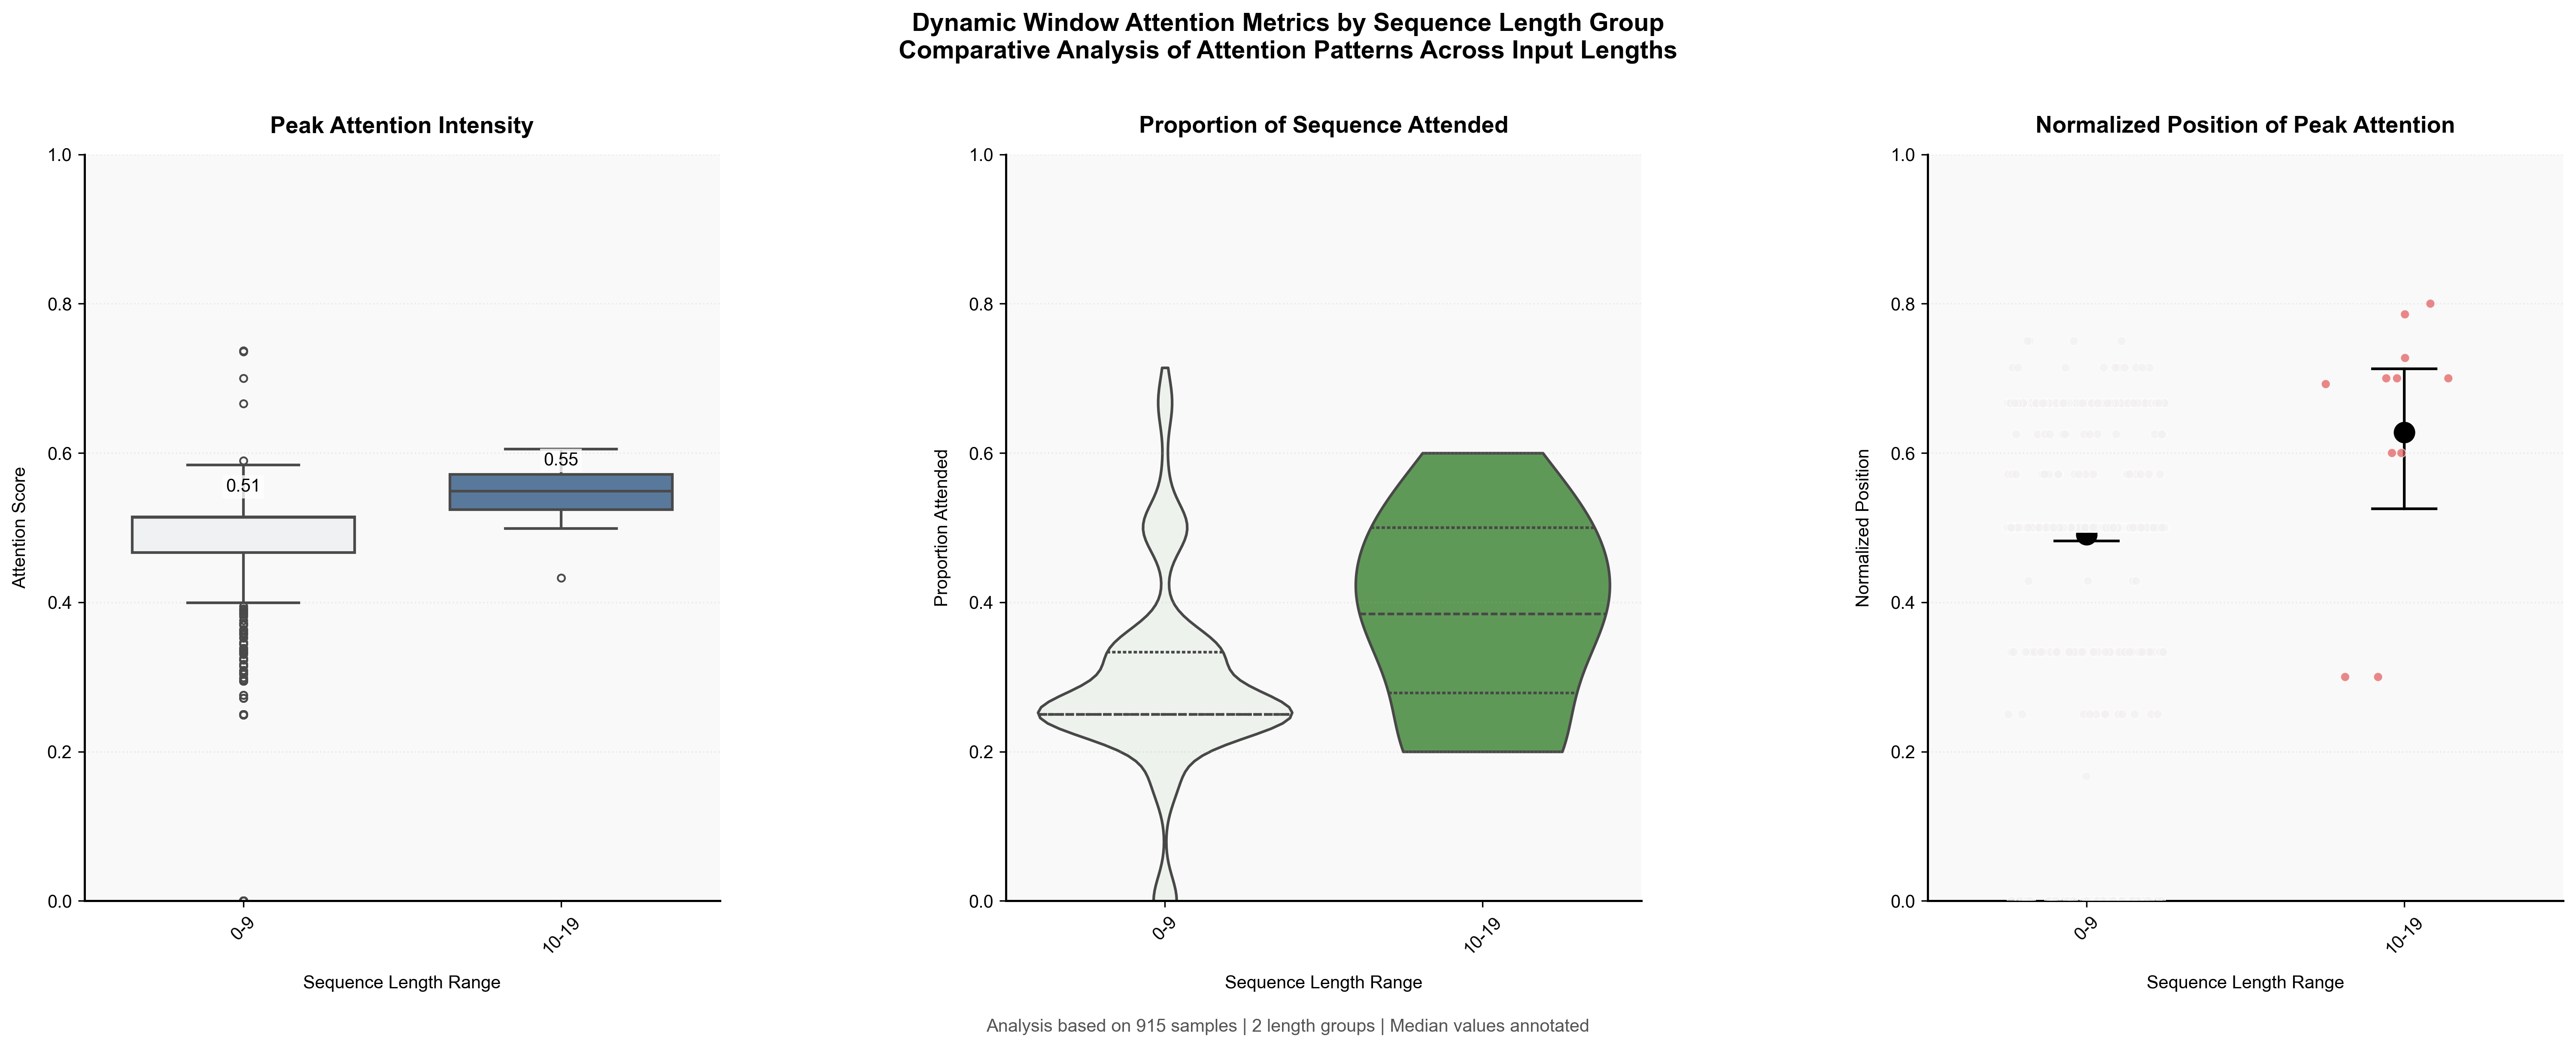

In [6]:
from timegnn import (
    get_length_bins_from_attention, compute_importance_stats,
    plot_heatmap_from_stats, plot_rank_dominance,
    plot_importance_timeline,
    plot_critical_windows, generate_pairwise_ttest_table,
    get_top_significant_ranges,
    calculate_window_metrics, plot_window_metrics,
)

attention = result.get("attention")

if attention:
    # ── Importance heatmap ──
    length_bins, _ = get_length_bins_from_attention(attention, bin_size=10)
    range_stats, range_importances, _ = compute_importance_stats(attention, length_bins)
    plot_heatmap_from_stats(range_stats, range_importances)

    # ── Rank dominance ──
    plot_rank_dominance(range_stats, title="Top-Node Dominance by Rank and Length")

    # ── Importance timeline for sequences of length 5–10 ──
    plot_importance_timeline(attention, min_length=5, max_length=10)

    # ── Statistical tests across temporal windows ──
    window_stats = plot_critical_windows(attention, length_bins, compare_ranges=None)
    pairwise = generate_pairwise_ttest_table(window_stats, length_bins)
    top_sig, _ = get_top_significant_ranges(pairwise, num_top=5)
    print(top_sig)

    # ── Window-level metrics ──
    df_metrics = calculate_window_metrics(attention, length_bins)
    plot_window_metrics(df_metrics)
else:
    print("No attention data was returned (increase num_epochs or check model config).")

## 5. Summary

The **Time-Aware GAT** introduces an exponential decay mechanism that
naturally captures the recency bias common in business processes.

Key takeaways:
- The decay parameter λ is **learnable** — the model decides how aggressively
  to discount the past.
- Attention maps reveal **which temporal positions** the model relies on most.
- For even richer representations, combine time decay with edge-type embeddings
  → see **`gat_time_decay_status_full`**.